In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/titanic/train.csv
/kaggle/input/titanic/test.csv
/kaggle/input/titanic/gender_submission.csv


# **Importing Libraries**

In [2]:
#importing libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# **Loading Train and Test Dataset** 

In [3]:
#reading dataset


train_data = pd.read_csv('/kaggle/input/titanic/train.csv')
test_data = pd.read_csv('/kaggle/input/titanic/test.csv')

In [4]:
#displaying first five rows

train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
# getting the number of rows and columns in the dataset

train_data.shape

(891, 12)

In [6]:
#basic statistical data


train_data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


# **EDA**

<AxesSubplot:>

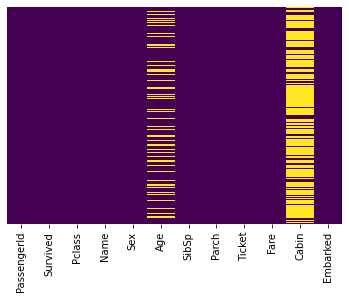

In [7]:
#heatmap to visualize missing values

sns.heatmap(train_data.isnull(),yticklabels=False,cbar=False,cmap='viridis')

In [8]:
#calculation of count of the total number of survived and deceased

train_data['Survived'].value_counts()

0    549
1    342
Name: Survived, dtype: int64

<AxesSubplot:xlabel='Survived', ylabel='count'>

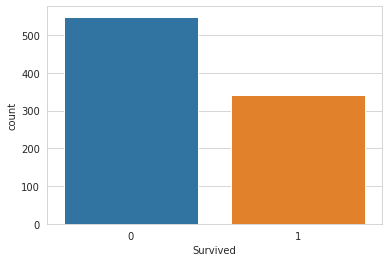

In [9]:
#Bar chart to visualize the survived

sns.set_style('whitegrid')
sns.countplot(x='Survived',data=train_data)

In [10]:
#calculating count of people in each passengerclass (Pclass)

train_data['Pclass'].value_counts()

3    491
1    216
2    184
Name: Pclass, dtype: int64

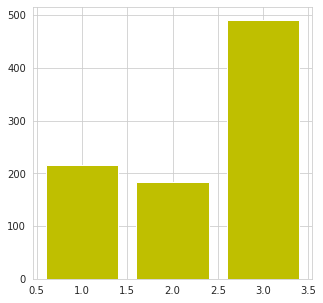

In [11]:
#Bar chart to visualize the count in each Pclass

plt.figure(figsize=(5,5))
plt.bar(list(train_data['Pclass'].value_counts().keys()),list(train_data['Pclass'].value_counts()),color=["y"])
plt.show()

In [12]:
#calculating count of people of each gender 


train_data['Sex'].value_counts()

male      577
female    314
Name: Sex, dtype: int64

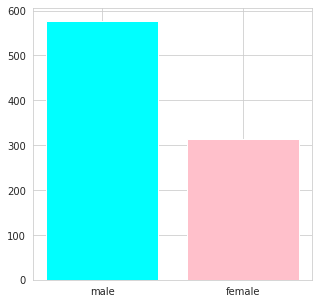

In [13]:
#Bar chart to visualize the count in each gender

plt.figure(figsize=(5,5))
plt.bar(list(train_data['Sex'].value_counts().keys()),list(train_data['Sex'].value_counts()),color=["cyan","pink"])
plt.show()

<AxesSubplot:xlabel='Survived', ylabel='count'>

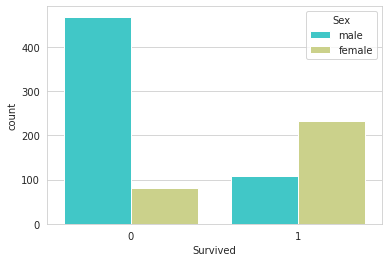

In [14]:
#visualizing survived for both genders

sns.set_style('whitegrid')
sns.countplot(x='Survived',hue='Sex',data=train_data,palette='rainbow')

<AxesSubplot:xlabel='Survived', ylabel='count'>

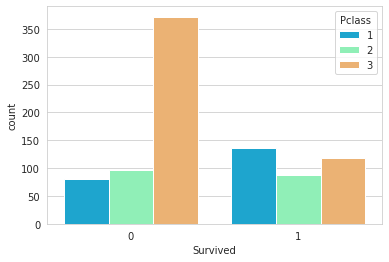

In [15]:
#visualizing survived for each Pclass

sns.set_style('whitegrid')
sns.countplot(x='Survived',hue='Pclass',data=train_data,palette='rainbow')

Text(0.5, 0, 'Age')

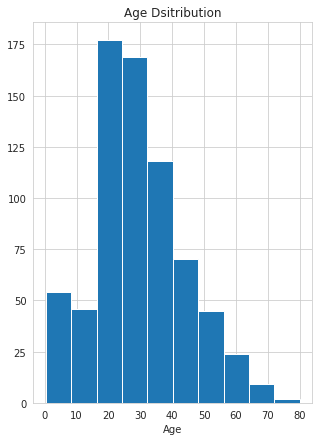

In [16]:
#Bar chart to visualize the Age distribution

plt.figure(figsize=(5,7))
plt.hist(train_data['Age'])
plt.title('Age Dsitribution')
plt.xlabel('Age')
#dusplt.show()

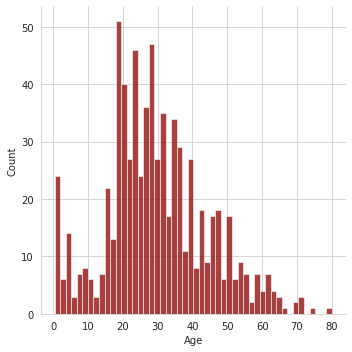

In [17]:
#distplot to visualize the Age distribution

sns.displot(train_data['Age'],kde=False,bins=50,color='darkred')

<AxesSubplot:xlabel='SibSp', ylabel='count'>

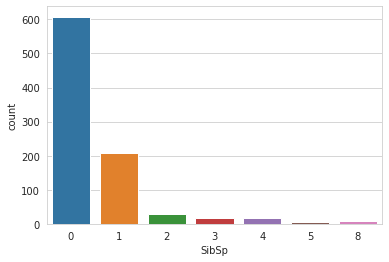

In [18]:
#count of SibSp using countplot


sns.countplot(x='SibSp',data=train_data)

<AxesSubplot:>

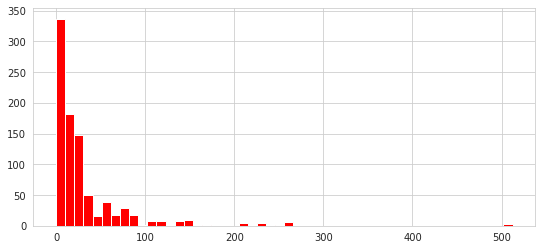

In [19]:
#Histogram Visualization for Fare column

train_data['Fare'].hist(color='r',bins=50,figsize=(9,4))

<AxesSubplot:xlabel='Pclass', ylabel='Age'>

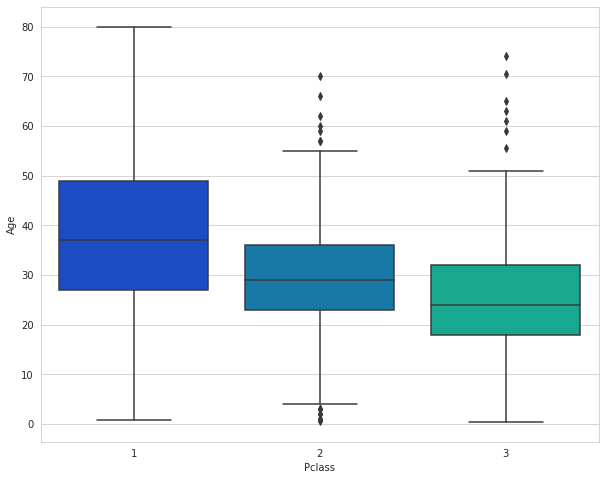

In [20]:
#BOXPLOT visualization to find the missing values

plt.figure(figsize=(10,8))
sns.boxplot(x='Pclass',y='Age',data=train_data,palette='winter')